# Querying HLS using the HLS STAC Geoparquet Archive

The [HLS STAC Geoparquet Archive](https://github.com/MAAP-Project/hls-stac-geoparquet-archive) is an unofficial archive of the HLS 2.0 granule STAC item metadata. It contains the STAC items that are generated as part of the HLS processing pipeline. The archive is produced and maintained by MAAP and is a non-rate-limited alternative to the CMR STAC API for users who need to access high volumes of HLS STAC records.

The data are stored in two hive-partitioned parquet datasets (one per collection, partitioned by year and month). The parquet files are generated monthly from CMR API Granule queries on the 15th of the following month (e.g. October 2025 files are generated on November 15 2025).

> Warning: This archive is not guaranteed to contain all of the records available in CMR

The parquet files can be accessed from the `nasa-maap-data-store` bucket in AWS S3 (us-west-2):

```
s3://nasa-maap-data-store/file-staging/nasa-map/hls-stac-geoparquet-archive/v2/{collection}/year={year}/month={month}/{collection}-{year}-{month}.parquet
```
where `collection` is either `HLSL30_2.0` (Landsat) or `HLSS30_2.0` (Sentinel-2).

The [rustac](https://stac-utils.github.io/rustac-py/latest/) package can be used to query the archive via the `DuckdbClient` interface. To use this approach your environment must be configured with AWS credentials that provide `ListBucket` access to the `nasa-maap-data-store` bucket in S3 (the following example will work in the MAAP Hub).

> Note: The HLSL30_2.0 and HLSS30_2.0 collections must be queried separately because the STAC items have slightly different parquet schemas.

Example DPS algorithms that use the HLS STAC Geoparquet Archive:

- [HLS Point Time Series](https://github.com/MAAP-Project/hls-point-time-series): extract HLS values for a set of provided point locations
- [HLS Cloud-Free Temporal Mosaic](https://github.com/MAAP-Project/hls-cloud-free-temporal-mosaic): generate cloud-free temporal mosaics (median value after masking bad pixels)

## Query example

In [2]:
from datetime import datetime, timedelta, UTC

import boto3
from rustac import DuckdbClient

aws_session = boto3.Session()
creds = aws_session.get_credentials().get_frozen_credentials()

client = DuckdbClient(use_hive_partitioning=True)

# configure duckdb to find S3 credentials for listing/reading the files in S3

# on the MAAP HUB
client.execute(
    f"""
    CREATE OR REPLACE SECRET secret (
        TYPE S3,
        REGION '{aws_session.region_name}',
        KEY_ID '{creds.access_key}',
        SECRET '{creds.secret_key}',
        SESSION_TOKEN '{creds.token}'
    );
    """
)

# on the MAAP ADE
# client.execute(
#     f"""
#     CREATE OR REPLACE SECRET secret (
#         TYPE S3,
#         PROVIDER credential_chain
#     );
#     """
# )

parquet_href = "s3://nasa-maap-data-store/file-staging/nasa-map/hls-stac-geoparquet-archive/v2/{collection}/**/*.parquet"

start_datetime = datetime(2025, 5, 1, tzinfo=UTC)
end_datetime = datetime(2025, 6, 1, tzinfo=UTC) - timedelta(seconds=1)

bbox = (-90, 45, -85, 50)

hls_l30_items = client.search(
    href=parquet_href.format(collection="HLSL30_2.0"),
    datetime="/".join(dt.isoformat() for dt in [start_datetime, end_datetime]),
    bbox=bbox,
)
print(f"found {len(hls_l30_items)} HLSL30_2.0 items")

hls_s30_items = client.search(
    href=parquet_href.format(collection="HLSS30_2.0"),
    datetime="/".join(dt.isoformat() for dt in [start_datetime, end_datetime]),
    bbox=bbox,
)
print(f"found {len(hls_s30_items)} HLSS30_2.0 items")

found 289 HLSL30_2.0 items
found 394 HLSS30_2.0 items


The resulting STAC items can be used to get the hrefs for the actual COG assets in the HLS collection.

## Direct S3 access to COGs

The hrefs provided in these STAC items are `https` urls, but if you are going to be reading the data in the AWS us-west-2 region, you should convert these hrefs to `s3://` urls then configure your code to read the files directly from S3 using credentials provided by LPDAAC. This will improve the performance and stability of any large-scale data access pipeline.

The `https` urls can be converted to `s3://` urls with a simple `str.replace` call:

In [3]:
import json

URL_PREFIX = "https://data.lpdaac.earthdatacloud.nasa.gov/"

for item in hls_l30_items:
    for key, asset in item["assets"].items():
        if asset["href"].endswith(".tif"):
            asset["href"] = asset["href"].replace(URL_PREFIX, "s3://")

print(json.dumps(hls_l30_items[0]["assets"]["Fmask"], indent=2))

{
  "href": "s3://lp-prod-protected/HLSL30.020/HLS.L30.T15TYK.2025126T164620.v2.0/HLS.L30.T15TYK.2025126T164620.v2.0.Fmask.tif",
  "type": "image/tiff; application=geotiff; profile=cloud-optimized",
  "roles": [
    "data"
  ],
  "eo:bands": [
    {
      "name": "Fmask"
    }
  ]
}


Then to read the file directly from S3 you need to request S3 credentials for the LPDAAC bucket and provide thsoe to `rasterio` via `AWSSession`:

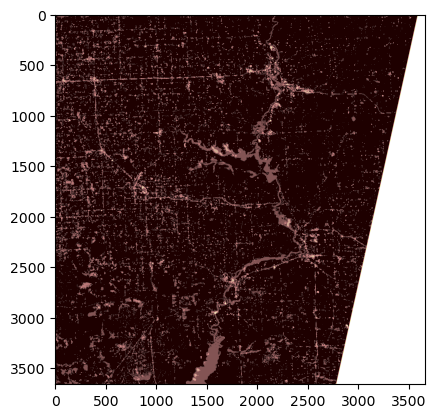

In [5]:
import rasterio
from maap.maap import MAAP
from matplotlib import pyplot
from rasterio.session import AWSSession

maap = MAAP("api.maap-project.org")

creds = maap.aws.earthdata_s3_credentials(
    "https://data.lpdaac.earthdatacloud.nasa.gov/s3credentials"
)

session = AWSSession(
    aws_access_key_id=creds["accessKeyId"],
    aws_secret_access_key=creds["secretAccessKey"],
    aws_session_token=creds["sessionToken"],
    region_name="us-west-2",
)

url = hls_l30_items[0]["assets"]["Fmask"]["href"]
with rasterio.Env(session=session):
    with rasterio.open(url) as src:
        pyplot.imshow(src.read(1), cmap="pink")